# Module 5 - Class 3: PCA on Mall Customers

**Dataset:** Mall Customer Segmentation  
**Objective:** Use PCA to reduce dimensions, visualize customer segments, and interpret principal components.

### What you will learn
- How PCA works (eigenvalue decomposition of covariance matrix)
- Scree plot and cumulative explained variance
- Reducing to 2D for visualization
- Interpreting PCA loadings in business terms

---

## 0. Setup

In [ ]:
import pandas as pd  # Import the pandas library to enable powerful, structured data manipulation and DataFrame analysis utilities
import numpy as np  # Import the numpy library for highly optimized multi-dimensional array operations and linear algebra computations
import matplotlib.pyplot as plt  # Import matplotlib.pyplot to build core static charts, layout subplots, and configure canvas properties
import seaborn as sns  # Import the seaborn library to leverage high-level, statistically optimized data visualization themes and plotting structures
from sklearn.preprocessing import StandardScaler  # Import StandardScaler to standardize features by centering to a zero mean and scaling to unit variance
from sklearn.decomposition import PCA  # Import PCA (Principal Component Analysis) to perform linear dimensionality reduction and identify maximum variance axes

import warnings  # Import the warnings module to manage runtime alert flags and streamline log outputs
warnings.filterwarnings('ignore')  # Configure the warning engine to suppress execution alerts, keeping the console output clean

print("Setup complete.")  # Output a milestone confirmation message indicating that all data analytics and visualization dependencies have loaded successfully

Setup complete.


## 1. Load Mall Customers Dataset

In [ ]:
url = "https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/Mall_Customers.csv"  # Define the string variable holding the remote GitHub URL for the raw mall customer profiling dataset
df = pd.read_csv(url)  # Fetch and parse the comma-separated tabular data from the remote web repository into a structured Pandas DataFrame instance

print(f"Shape: {df.shape}")  # Output the shape dimensions (total row count and column count) of the imported customer dataset to the console
print(f"\nColumns: {df.columns.tolist()}")  # Retrieve and display the complete ordered sequence of dataset column header strings as a standard Python list
print(f"\nFirst 5 rows:")  # Output a section marker to the console ahead of rendering the initial dataset preview rows
df.head()  # Extract and display the first five observational records from the loaded DataFrame to inspect the underlying data types and value layouts

Shape: (200, 5)

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Select numeric features for PCA
# Encode Gender as 0/1
df['Gender_encoded'] = (df['Gender'] == 'Male').astype(int)  # Map the categorical values in 'Gender' to a binary integer encoding, where Male is represented as 1 and Female as 0

features = ['Gender_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']  # Define the final subset of quantitative and encoded feature labels to use for dimensionality reduction
X = df[features].copy()  # Isolate and create a hard copy of the target feature columns into a dedicated analysis DataFrame

print("Features for PCA:")  # Output a section marker to the console identifying the downstream statistical summaries
print(X.describe().round(2))  # Generate and print a comprehensive summary matrix of descriptive statistics (mean, min, max, standard deviations) rounded to 2 decimal places

Features for PCA:
       Gender_encoded     Age  Annual Income (k$)  Spending Score (1-100)
count          200.00  200.00              200.00                  200.00
mean             0.44   38.85               60.56                   50.20
std              0.50   13.97               26.26                   25.82
min              0.00   18.00               15.00                    1.00
25%              0.00   28.75               41.50                   34.75
50%              0.00   36.00               61.50                   50.00
75%              1.00   49.00               78.00                   73.00
max              1.00   70.00              137.00                   99.00


## 2. Standardize Features

PCA is sensitive to feature scale — features with larger ranges will dominate the principal components.

In [ ]:
scaler = StandardScaler()  # Initialize the standardizer to transform features by centering them to a zero mean and scaling to unit variance
X_scaled = scaler.fit_transform(X)  # Compute the empirical mean and standard deviation for each feature, then apply the standardization matrix transformation

print("After scaling (mean ~ 0, std ~ 1):")  # Output a section marker to indicate that the downstream descriptive summary represents normalized features
print(pd.DataFrame(X_scaled, columns=features).describe().round(2))  # Convert the scaled NumPy array back into a structured DataFrame and print its statistical summary rounded to 2 decimal places to verify normalization

After scaling (mean ~ 0, std ~ 1):
       Gender_encoded     Age  Annual Income (k$)  Spending Score (1-100)
count          200.00  200.00              200.00                  200.00
mean             0.00   -0.00               -0.00                   -0.00
std              1.00    1.00                1.00                    1.00
min             -0.89   -1.50               -1.74                   -1.91
25%             -0.89   -0.72               -0.73                   -0.60
50%             -0.89   -0.20                0.04                   -0.01
75%              1.13    0.73                0.67                    0.89
max              1.13    2.24                2.92                    1.89


## 3. PCA with All Components

In [ ]:
pca_full = PCA(n_components=4)  # Initialize the Principal Component Analysis model to reduce the dataset's dimensionality down to 4 target components
X_pca_full = pca_full.fit_transform(X_scaled)  # Fit the PCA model on the scaled features to learn the orthogonal axes and project the data into the new principal component space

print("Explained Variance Ratio per Component:")  # Output a section marker to indicate that the subsequent printed lines will list individual component variances
for i, var in enumerate(pca_full.explained_variance_ratio_):  # Iterate through the array of explained variance ratios to extract the proportion of information captured by each component
    print(f"   PC{i+1}: {var:.4f} ({var*100:.1f}%)")  # Display the identifier for each principal component along with its individual variance contribution formatted as both a decimal and a percentage

print(f"\nTotal explained variance: {pca_full.explained_variance_ratio_.sum()*100:.1f}%")  # Calculate and display the cumulative explained variance across all 4 components to evaluate the total information retained by the reduction

Explained Variance Ratio per Component:
   PC1: 0.3369 (33.7%)
   PC2: 0.2623 (26.2%)
   PC3: 0.2326 (23.3%)
   PC4: 0.1682 (16.8%)

Total explained variance: 100.0%


## 4. Scree Plot

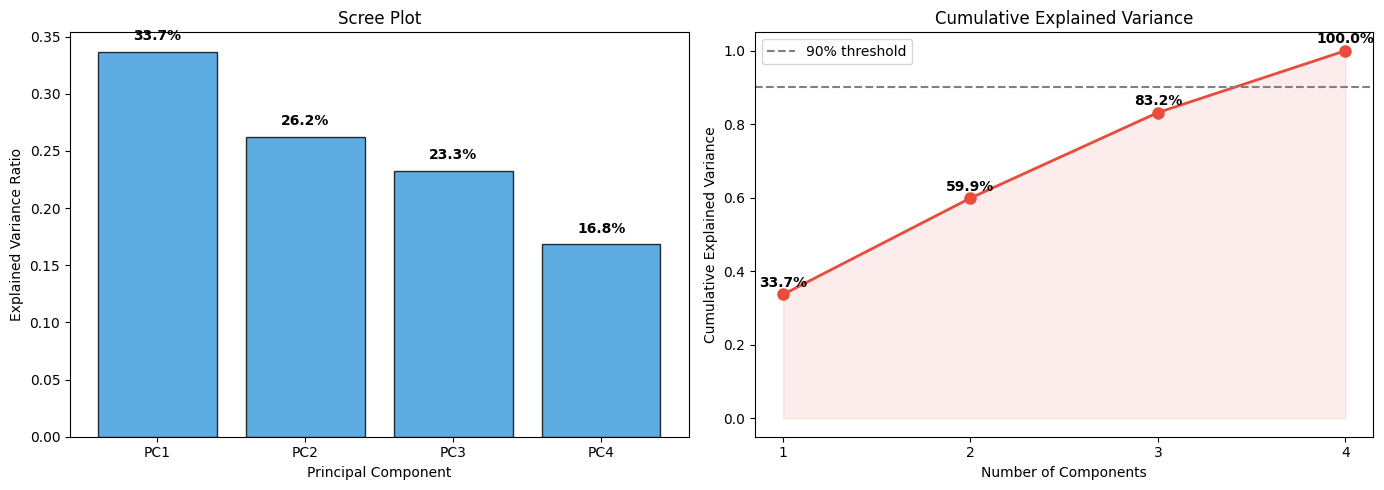

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Create a figure canvas with a 1-row, 2-column subplot grid configuration and specify custom dimensions in inches

components = range(1, 5)  # Define a discrete range of integer identifiers representing the sequential principal components for the x-axis plotting
var_ratio = pca_full.explained_variance_ratio_  # Extract the array containing the individual proportions of variance captured by each respective principal component
cumulative = np.cumsum(var_ratio)  # Compute the running cumulative sum of the variance ratios to track the total information retained sequentially

# Scree plot
axes[0].bar(components, var_ratio, color='#3498db', alpha=0.8, edgecolor='black')  # Render a vertical bar chart on the first subplot to visually represent individual component variances with specified styling
axes[0].set_xlabel('Principal Component')  # Set the descriptive label for the horizontal axis of the first subplot to identify the individual components
axes[0].set_ylabel('Explained Variance Ratio')  # Set the descriptive label for the vertical axis of the first subplot to measure the individual variance proportions
axes[0].set_title('Scree Plot')  # Assign a clear title to the first subplot to specify that it functions as a standard scree plot analysis
axes[0].set_xticks(list(components))  # Establish explicit tick mark locations on the x-axis matching the discrete component numbers exactly
axes[0].set_xticklabels([f'PC{i}' for i in components])  # Map custom formatted string labels to the x-axis ticks to distinctly label each principal component
for i, v in enumerate(var_ratio):  # Iterate through the individual variance ratios to dynamically position numeric labels above each corresponding bar
    axes[0].text(i+1, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')  # Overlay the percentage text values directly above the bars with bold formatting for clear visual readability

# Cumulative explained variance
axes[1].plot(components, cumulative, 'o-', color='#e74c3c', linewidth=2, markersize=8)  # Plot a styled line graph with circular markers on the second subplot to display the cumulative variance trend
axes[1].axhline(y=0.9, color='gray', linestyle='--', label='90% threshold')  # Draw a dashed horizontal reference line at the 90% mark to signify a common information retention threshold
axes[1].fill_between(components, cumulative, alpha=0.1, color='#e74c3c')  # Shade the geometric region underneath the cumulative line plot to visually emphasize the total variance accumulation area
axes[1].set_xlabel('Number of Components')  # Set the descriptive label for the horizontal axis of the second subplot to show the count of included components
axes[1].set_ylabel('Cumulative Explained Variance')  # Set the descriptive label for the vertical axis of the second subplot to measure the total accumulated variance
axes[1].set_title('Cumulative Explained Variance')  # Assign a clear title to the second subplot to specify that it tracks the cumulative information retention
axes[1].set_xticks(list(components))  # Establish explicit tick mark locations on the x-axis for the cumulative plot to maintain consistency
axes[1].legend()  # Display the plot legend to identify the 90% threshold reference line within the cumulative subplot area
for i, v in enumerate(cumulative):  # Iterate through the cumulative variance array values to dynamically position text annotations along the line graph
    axes[1].text(i+1, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')  # Overlay bold percentage text values slightly above each data point to indicate precise cumulative retention totals

plt.tight_layout()  # Adjust the bounding boxes and margins of the subplots automatically to prevent any overlapping of text labels or axis titles
plt.show()  # Render the completed multi-panel data visualization figure on the screen for analytical review

## 5. Reduce to 2 Components and Scatter Plot

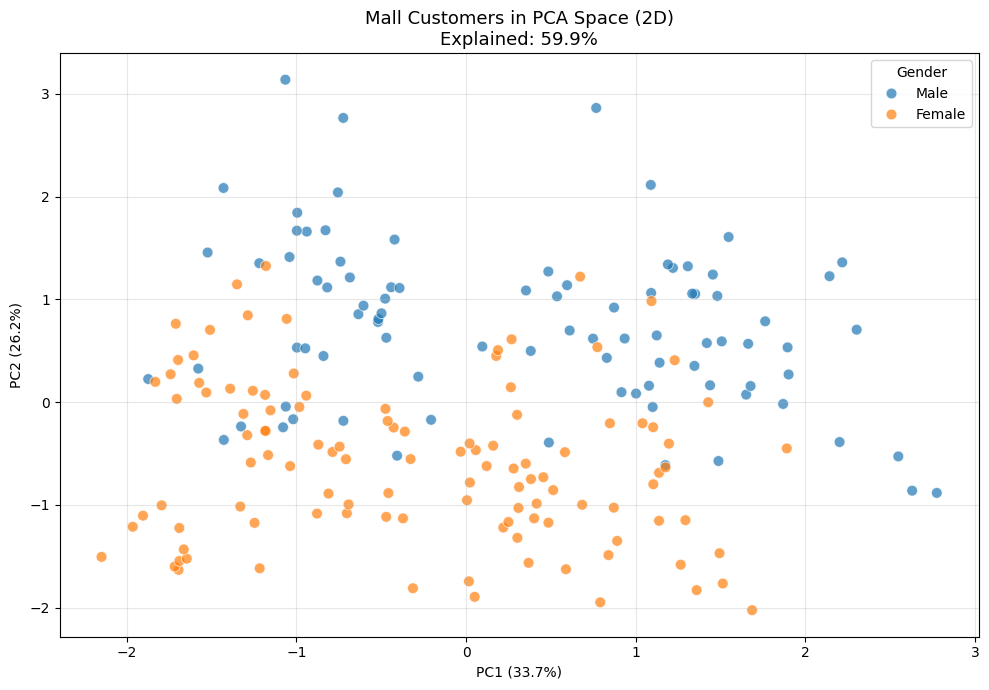

In [ ]:
pca_2d = PCA(n_components=2)  # Initialize the Principal Component Analysis model to project the dataset's dimensionality down into a 2-dimensional plane
X_pca_2d = pca_2d.fit_transform(X_scaled)  # Fit the PCA model on the scaled features and transform them into a 2-component orthogonal coordinate space

pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])  # Convert the 2-dimensional NumPy array into a structured pandas DataFrame with explicit principal component column names
pca_df['Gender'] = df['Gender'].values  # Extract the raw categorical values of the 'Gender' feature from the original DataFrame and append them to the PCA DataFrame for color-coding

plt.figure(figsize=(10, 7))  # Initialize a new figure canvas with explicit width and height dimensions in inches to ensure clear visual spacing
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Gender', alpha=0.7, s=60)  # Render a 2D scatter plot using Seaborn, mapping the principal components to the axes and distinguishing categories by color with custom transparency and marker sizing
plt.title(f'Mall Customers in PCA Space (2D)\nExplained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%', fontsize=13)  # Apply a descriptive plot title that dynamically computes and displays the cumulative variance explained by both components
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')  # Set the horizontal axis label, embedding the exact individual percentage of total variance captured by the first principal component
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')  # Set the vertical axis label, embedding the exact individual percentage of total variance captured by the second principal component
plt.grid(True, alpha=0.3)  # Superimpose a subtle background grid with controlled opacity to assist in the geometric alignment and estimation of individual data points
plt.tight_layout()  # Automatically adjust subplots and margins to optimize spacing and prevent any bounding box label clipping
plt.show()  # Render the completed 2D visual projection of the dataset onto the screen for cluster and categorical analysis

## 6. PCA Loadings

Loadings tell us how much each original feature contributes to each principal component.

PCA Loadings (how original features map to components):
                           PC1     PC2     PC3     PC4
Gender_encoded          0.2343  0.6269  0.7430 -0.0074
Age                     0.6879 -0.1037 -0.1224  0.7079
Annual Income (k$)     -0.0061  0.7653 -0.6437  0.0067
Spending Score (1-100) -0.6869  0.1032  0.1366  0.7063



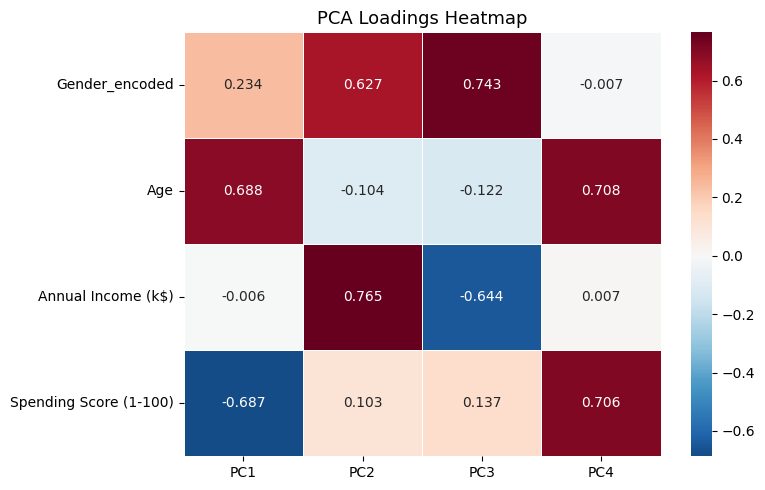

In [ ]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(4)],
    index=features
)  # Construct a structured pandas DataFrame by transposing the PCA components matrix so that original features align as rows and principal components align as columns

print("PCA Loadings (how original features map to components):")  # Output a section marker to clarify that the subsequent console matrix displays the linear combination weights of the features
print(loadings.round(4))  # Print the structural weights matrix rounded to 4 decimal places to evaluate the strength and direction of each feature's contribution to the components
print()  # Insert an empty line break in the console output to maintain clean spacing before any subsequent logs

# Heatmap
plt.figure(figsize=(8, 5))  # Initialize a separate figure canvas with specific width and height dimensions in inches to optimize the visualization layout
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0, linewidths=0.5)  # Render a color-coded matrix plot overlaying numerical text values formatted to 3 decimal places using a divergent color scheme centered at zero
plt.title('PCA Loadings Heatmap', fontsize=13)  # Assign an explicit descriptive title to the heatmap figure with a controlled font size for clear interpretation
plt.tight_layout()  # Adjust the bounding boxes and margins of the visualization layout automatically to prevent any axis or label clipping
plt.show()  # Render the completed matrix visualization onto the screen to visually audit feature-to-component correlations

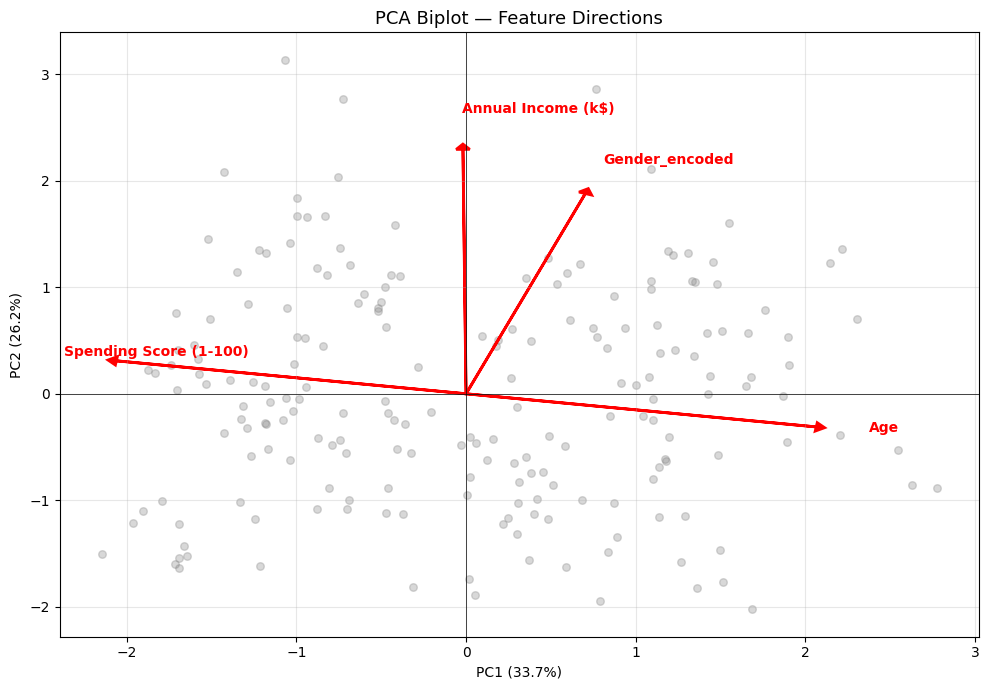

In [ ]:
# Biplot: vectors showing feature directions in PC1-PC2 space
plt.figure(figsize=(10, 7))  # Initialize a new figure canvas with explicit width and height dimensions in inches to guarantee a clear visual layout for the biplot

# Scatter points
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.3, s=30, color='gray')  # Render the background scatter plot of data points projected onto the 2D PCA space using low opacity to keep focus on the vectors

# Feature vectors
scale = 3  # Define a uniform scaling factor to artificially lengthen the feature vectors for better visual overlay and alignment within the scatter field
for i, feat in enumerate(features):  # Iterate sequentially through the list of original dataset features to map each individual loading weight to its spatial vector
    plt.arrow(0, 0,
              loadings.iloc[i, 0] * scale,
              loadings.iloc[i, 1] * scale,
              head_width=0.08, head_length=0.05, fc='red', ec='red', linewidth=2)  # Draw a directed arrow from the coordinate origin reflecting the magnitude and direction of the feature's loading on PC1 and PC2
    plt.text(loadings.iloc[i, 0] * scale * 1.15,
             loadings.iloc[i, 1] * scale * 1.15,
             feat, fontsize=10, fontweight='bold', color='red')  # Annotate the tip of each directional arrow with its respective feature name label, adding a slight offset multiplier to prevent overlapping the arrowhead

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')  # Set the horizontal axis label, embedding the exact individual percentage of total variance captured by the first principal component
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')  # Set the vertical axis label, embedding the exact individual percentage of total variance captured by the second principal component
plt.title('PCA Biplot — Feature Directions', fontsize=13)  # Apply an explicit, descriptive title to the biplot figure using a controlled font size for clear interpretation
plt.axhline(y=0, color='black', linewidth=0.5)  # Superimpose a solid horizontal reference line at zero to visually define the boundary between positive and negative PC2 coordinates
plt.axvline(x=0, color='black', linewidth=0.5)  # Superimpose a solid vertical reference line at zero to visually define the boundary between positive and negative PC1 coordinates
plt.grid(True, alpha=0.3)  # Superimpose a subtle background grid with controlled opacity to assist in the geometric alignment and estimation of data distribution trends
plt.tight_layout()  # Automatically adjust subplots and margins to optimize spacing and prevent any bounding box label clipping
plt.show()  # Render the completed PCA biplot visualization onto the screen for correlation and multi-dimensional analysis

## 7. TODO: Interpret the Principal Components

Look at the loadings table and biplot above, then answer:

1. **PC1 interpretation:** Which original features contribute most to PC1? What does PC1 represent in business terms? (e.g., does it separate rich vs poor customers? young vs old?)

2. **PC2 interpretation:** Which features dominate PC2? What business meaning does this axis carry?

3. How many components would you keep if you wanted to retain at least 90% of the variance?

**TODO: Your interpretation here**

*Write your answer in this cell.*


In [ ]:
"""
Interpretation of Principal Components:

1.  **PC1 interpretation:**
    *   **Features contributing most:** PC1 is strongly influenced by 'Age' (positive loading ~0.69) and 'Spending Score (1-100)' (negative loading ~-0.69). 'Gender_encoded' and 'Annual Income (k$)' have much smaller loadings.
    *   **Business terms:** This suggests PC1 primarily differentiates customers based on their age and spending behavior. A high PC1 score would correspond to older customers with lower spending scores, while a low PC1 score would correspond to younger customers with higher spending scores. It represents a 'Youthful Spender vs. Mature Conservative' dimension.

2.  **PC2 interpretation:**
    *   **Features dominating:** PC2 is mainly dominated by 'Annual Income (k$)' (positive loading ~0.77) and 'Gender_encoded' (positive loading ~0.63). 'Age' and 'Spending Score' have much smaller absolute loadings.
    *   **Business terms:** This indicates PC2 largely captures variance related to customers' annual income and gender. A high PC2 score would suggest customers with higher annual incomes, tending to be male, while a low PC2 score would suggest customers with lower annual incomes, tending to be female. It represents an 'Affluent Male vs. Modest Female' dimension.

3.  **Components for 90% variance:**
    *   Based on the cumulative explained variance, 3 components retain 83.2% of the variance. To retain **at least 90%** of the variance, we would need to keep **4 components**, as this captures 100% of the variance in this dataset.
"""

"\nInterpretation of Principal Components:\n\n1.  **PC1 interpretation:**\n    *   **Features contributing most:** PC1 is strongly influenced by 'Age' (positive loading ~0.69) and 'Spending Score (1-100)' (negative loading ~-0.69). 'Gender_encoded' and 'Annual Income (k$)' have much smaller loadings.\n    *   **Business terms:** This suggests PC1 primarily differentiates customers based on their age and spending behavior. A high PC1 score would correspond to older customers with lower spending scores, while a low PC1 score would correspond to younger customers with higher spending scores. It represents a 'Youthful Spender vs. Mature Conservative' dimension.\n\n2.  **PC2 interpretation:**\n    *   **Features dominating:** PC2 is mainly dominated by 'Annual Income (k$)' (positive loading ~0.77) and 'Gender_encoded' (positive loading ~0.63). 'Age' and 'Spending Score' have much smaller absolute loadings.\n    *   **Business terms:** This indicates PC2 largely captures variance related to 

---
## Summary

| Concept | Details |
|---------|--------|
| PCA | Projects data onto directions of maximum variance |
| Standardization | Required before PCA — features must be on the same scale |
| Scree Plot | Shows variance per component — look for the "elbow" |
| Cumulative Variance | Helps decide how many components to keep (e.g., 90% threshold) |
| Loadings | Coefficients mapping original features to principal components |
| Biplot | Overlays feature vectors on the PCA scatter — shows feature directions |